In this project, I analyzed health insurance claims data to determine whether different obesity classes exhibit significantly different claim costs. Based off those results, I used Monte Carlo simulations to recommend actuarially sound premium prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

First, I examined the dataset. I checked to see if there are any missing values I needed to address/fill, in addition to getting a picture of the properties of the dataset. 

In [2]:
df = pd.read_csv("insurance.csv")

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1338, 7)

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Summary Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwes

Since this project deals with claim sizes and obesity classes, I generated a scatterplot using matplotlib to visualize the relationship between BMI and claim sizes.

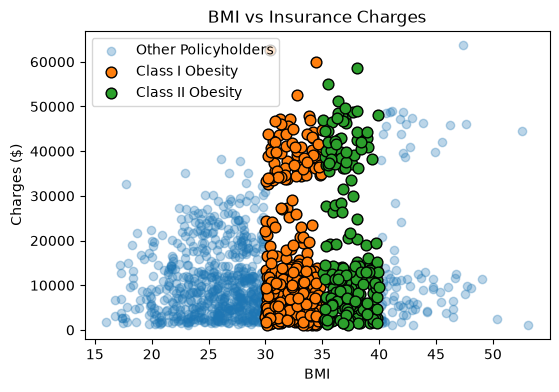

In [3]:
class1 = df[(df["bmi"] >= 30.0) & (df["bmi"] < 35.0)]
class2 = df[(df["bmi"] >= 35.0) & (df["bmi"] < 40.0)]

plt.figure(figsize=(6,4))

plt.scatter(
    df["bmi"],
    df["charges"],
    alpha=0.3,
    label="Other Policyholders"
)

plt.scatter(
    class1["bmi"],
    class1["charges"],
    s=60,
    edgecolors='black',
    linewidth=1,
    label="Class I Obesity"
)

plt.scatter(
    class2["bmi"],
    class2["charges"],
    s=60,
    edgecolors='black',
    linewidth=1,
    label="Class II Obesity"
)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges ($)")
plt.legend()
plt.show()

Evidently, there is a visible positive correlation between BMI and claim size. However, it is less obvious whether or not there is a statistically signifcant difference in average claim size between policyholders that fall under class 1 obesity versus those that fall under class 2 obesity. 

To investigate this, I conducted a hypothesis test using a two-sample t-test and a significance level of 5%. The t-test is the best test to use because the true variances of the claim sizes are unknown.

Under the null hypothesis, I assume that the average claim size between the two classes is equal, while the alternative hypothesis assumes that the average claim size of class 2 obesity policyholders is larger than those of class 1 obesity policyholders.

In [4]:
from scipy.stats import ttest_ind

class1 = df[(df["bmi"] >= 30.0) & (df["bmi"] < 35.0)]["charges"]

class2 = df[(df["bmi"] >= 35.0) & (df["bmi"] < 40.0)]["charges"]

print("Class I Obesity Sample Size:", len(class1))
print("Class II Obesity Sample Size:", len(class2))

print("\nAverage Claim Amounts")
print("Class I:", round(class1.mean(), 2))
print("Class II:", round(class2.mean(), 2))

t_stat, p_value = ttest_ind(class2, class1, equal_var=False)

print("\nHypothesis Test Results")
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 5))

one_sided_p = p_value / 2

print("One-sided p-value:", round(one_sided_p, 5))

alpha = 0.05

if one_sided_p < alpha:
    print("Reject H0: Class II obesity has significantly higher average claim costs.")
else:
    print("Fail to reject H0: There is insufficient evidence that Class II obesity has higher average claim costs.")

Class I Obesity Sample Size: 391
Class II Obesity Sample Size: 225

Average Claim Amounts
Class I: 14419.67
Class II: 17022.26

Hypothesis Test Results
t-statistic: 2.129
p-value: 0.03382
One-sided p-value: 0.01691
Reject H0: Class II obesity has significantly higher average claim costs.


As the hypothesis test shows, there is statistical evidence that on average, class 2 obesity policyholders incur higher claim costs than class 1 obesity policyholders. Thus, it would be logical to set separate premium prices for individuals depending on which demographic they fall in.

To set a premium price for class 1 obesity, I used a Monte Carlo simulation to model future annual portfolio losses. I simulated a portfolio consisting of 1,000 policyholders 10,0000 times by conducting random sampling of historical claim amounts made by class 1 policyholders, with replacement.

The premium price was calculated by multiplying the 95th percentile of average insurance claims (to ensure the insurance company can adequately cover losses in extreme years) by a loading factor of 10% to account for administrative expenses, profit, and other risks.

Class I Obesity Monte Carlo Simulation and Suggested Premium Calculation
--------------------------------------
Portfolio Size: 1000
Number of Simulations: 10000

Expected Total Portfolio Loss: $14,412,889.00
95th Percentile Total Portfolio Loss: $15,140,016.07

Expected Cost per Policyholder: $14,412.89
Recommended Premium: $16,654.02


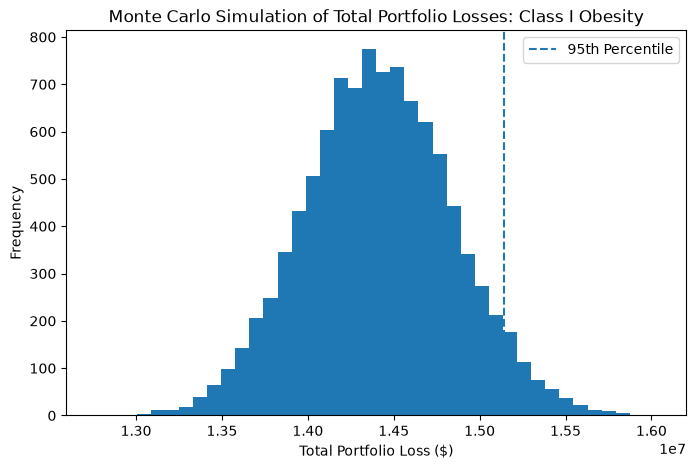

In [5]:
class1_claims = df[(df["bmi"] >= 30.0) & (df["bmi"] < 35.0)]["charges"]

np.random.seed(1)
n_simulations = 10000
portfolio_size = 1000

total_losses_class1 = []

for i in range(n_simulations):
    simulated_claims = np.random.choice(
        class1_claims,
        size=portfolio_size,
        replace=True
    )
    
    total_loss = simulated_claims.sum()
    total_losses_class1.append(total_loss)

total_losses_class1 = np.array(total_losses_class1)

expected_total_loss = total_losses_class1.mean()
percentile_95_loss = np.percentile(total_losses_class1, 95)

expected_cost_per_policyholder = expected_total_loss / portfolio_size
loading_factor = 1.1
premium = percentile_95_loss / portfolio_size * loading_factor

print("Class I Obesity Monte Carlo Simulation and Suggested Premium Calculation")
print("--------------------------------------")
print(f"Portfolio Size: {portfolio_size}")
print(f"Number of Simulations: {n_simulations}")

print(f"\nExpected Total Portfolio Loss: ${expected_total_loss:,.2f}")
print(f"95th Percentile Total Portfolio Loss: ${percentile_95_loss:,.2f}")

print(f"\nExpected Cost per Policyholder: ${expected_cost_per_policyholder:,.2f}")
print(f"Recommended Premium: ${premium:,.2f}")

plt.figure(figsize=(8, 5))
plt.hist(total_losses_class1, bins=40)
plt.axvline(percentile_95_loss, linestyle="--", label="95th Percentile")
plt.title("Monte Carlo Simulation of Total Portfolio Losses: Class I Obesity")
plt.xlabel("Total Portfolio Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The same process was repeated to set a premium price for class 2 policyholders.

Class II Obesity Monte Carlo Simulation and Suggested Premium Calculation
----------------------------------------------------------
Portfolio Size: 1000
Number of Simulations: 10000

Expected Total Portfolio Loss: $17,025,946.08
95th Percentile Total Portfolio Loss: $17,802,974.55

Expected Cost per Policyholder: $17,025.95
Recommended Premium: $19,583.27


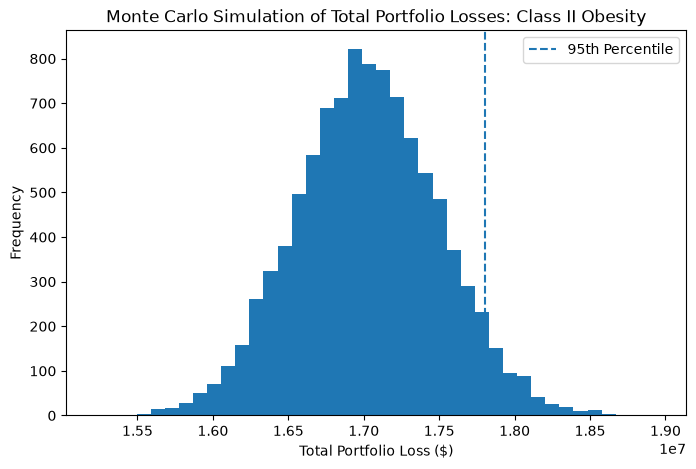

In [6]:
class2_claims = df[(df["bmi"] >= 35.0) & (df["bmi"] < 40.0)]["charges"]

np.random.seed(1)
n_simulations = 10000
portfolio_size = 1000

total_losses_class2 = []

for i in range(n_simulations):
    simulated_claims = np.random.choice(
        class2_claims,
        size=portfolio_size,
        replace=True
    )
    
    total_loss = simulated_claims.sum()
    total_losses_class2.append(total_loss)

total_losses_class2 = np.array(total_losses_class2)

expected_total_loss_class2 = total_losses_class2.mean()
percentile_95_loss_class2 = np.percentile(total_losses_class2, 95)

expected_cost_per_policyholder_class2 = (
    expected_total_loss_class2 / portfolio_size
)

loading_factor = 1.10

premium_class2 = (
    percentile_95_loss_class2 / portfolio_size * loading_factor
)

print("Class II Obesity Monte Carlo Simulation and Suggested Premium Calculation")
print("----------------------------------------------------------")
print(f"Portfolio Size: {portfolio_size}")
print(f"Number of Simulations: {n_simulations}")

print(f"\nExpected Total Portfolio Loss: ${expected_total_loss_class2:,.2f}")
print(f"95th Percentile Total Portfolio Loss: ${percentile_95_loss_class2:,.2f}")

print(f"\nExpected Cost per Policyholder: ${expected_cost_per_policyholder_class2:,.2f}")
print(f"Recommended Premium: ${premium_class2:,.2f}")

plt.figure(figsize=(8, 5))
plt.hist(total_losses_class2, bins=40)
plt.axvline(
    percentile_95_loss_class2,
    linestyle="--",
    label="95th Percentile"
)

plt.title("Monte Carlo Simulation of Total Portfolio Losses: Class II Obesity")
plt.xlabel("Total Portfolio Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The recommended premium for class 2 policyholders was substantially larger than the premium recommended for class 1 policyholders. This result is consistent with the hypothesis testing results, which indicated that higher obesity severity is associated with increased insurance claim costs.